In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [7]:
df = pd.read_csv('AQI_Data_Set.csv')   
print("Shape:", df.shape)
df.head(10)

Shape: (3301, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",30-03-2026 08:00,25.265194,87.012947,NH3,5.0,7.0,6.0
1,India,Bihar,Bhagalpur,"Mayaganj, Bhagalpur - BSPCB",30-03-2026 08:00,25.265194,87.012947,OZONE,4.0,11.0,8.0
2,India,Bihar,Bihar Sharif,"D M Colony, Bihar Sharif - BSPCB",30-03-2026 08:00,25.204762,85.514960,OZONE,2.0,2.0,2.0
3,India,Bihar,Buxar,"Charitra Van, Buxar - BSPCB",30-03-2026 08:00,25.567520,83.966379,PM10,40.0,73.0,56.0
4,India,Bihar,Buxar,"Charitra Van, Buxar - BSPCB",30-03-2026 08:00,25.567520,83.966379,NO2,9.0,10.0,9.0
5,India,Bihar,Chhapra,"Darshan Nagar, Chhapra - BSPCB",30-03-2026 08:00,25.780826,84.744677,NH3,9.0,18.0,15.0
6,India,Bihar,Chhapra,"Darshan Nagar, Chhapra - BSPCB",30-03-2026 08:00,25.780826,84.744677,SO2,20.0,23.0,21.0
7,India,Bihar,Chhapra,"Darshan Nagar, Chhapra - BSPCB",30-03-2026 08:00,25.780826,84.744677,OZONE,2.0,9.0,3.0
8,India,Bihar,Gaya,"Collectorate, Gaya - BSPCB",30-03-2026 08:00,24.795500,84.999400,PM2.5,32.0,307.0,112.0
9,India,Andhra_Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",30-03-2026 08:00,14.438164,79.966814,NO2,14.0,18.0,16.0


In [8]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nUnique Pollutants:", df['pollutant_id'].unique())
print("\nUnique States:", df['state'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3301 entries, 0 to 3300
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3301 non-null   object 
 1   state          3301 non-null   object 
 2   city           3301 non-null   object 
 3   station        3301 non-null   object 
 4   last_update    3301 non-null   object 
 5   latitude       3301 non-null   float64
 6   longitude      3301 non-null   float64
 7   pollutant_id   3301 non-null   object 
 8   pollutant_min  3113 non-null   float64
 9   pollutant_max  3113 non-null   float64
 10  pollutant_avg  3113 non-null   float64
dtypes: float64(5), object(6)
memory usage: 283.8+ KB
None

Missing Values:
 country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    188
pollutant_max    188
pollutant_avg    188
dtype: int64


In [9]:
print("Statistical Summary")
df[['pollutant_min', 'pollutant_max', 'pollutant_avg']].describe()

Statistical Summary


,pollutant_min,pollutant_max,pollutant_avg
count,3113.000000,3113.000000,3113.000000
mean,22.572438,65.085127,37.254738
std,26.152791,73.575513,39.882648
min,1.000000,1.000000,1.000000
25%,5.000000,16.000000,10.000000
50%,13.000000,42.000000,24.000000
75%,30.000000,86.000000,50.000000
max,210.000000,500.000000,294.000000


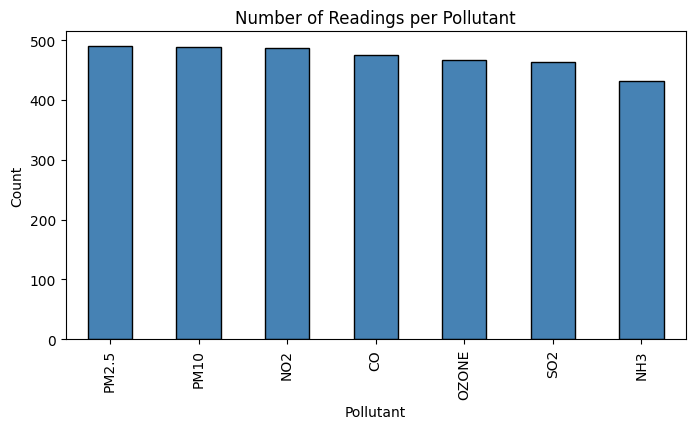

In [10]:
plt.figure(figsize=(8, 4))
df['pollutant_id'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Readings per Pollutant')
plt.xlabel('Pollutant')
plt.ylabel('Count')
plt.show()

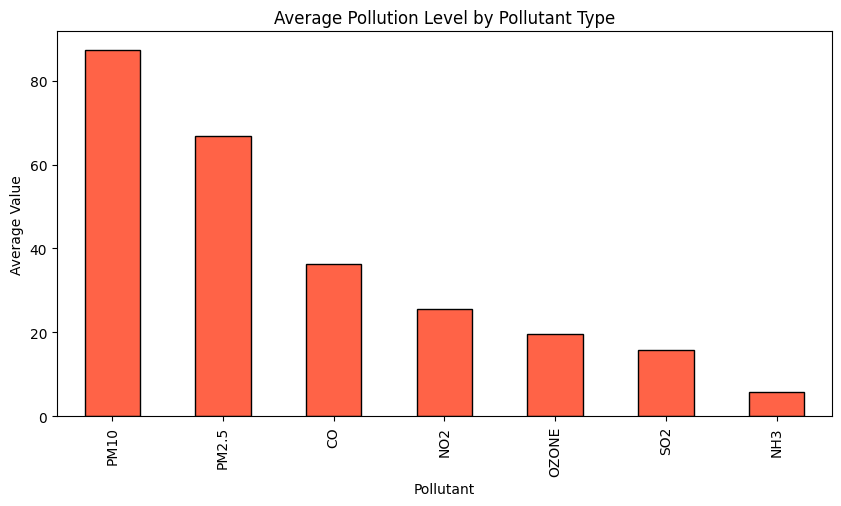

In [11]:
plt.figure(figsize=(10, 5))
df.groupby('pollutant_id')['pollutant_avg'].mean().sort_values(ascending=False).plot(
    kind='bar', color='tomato', edgecolor='black')
plt.title('Average Pollution Level by Pollutant Type')
plt.xlabel('Pollutant')
plt.ylabel('Average Value')
plt.show()

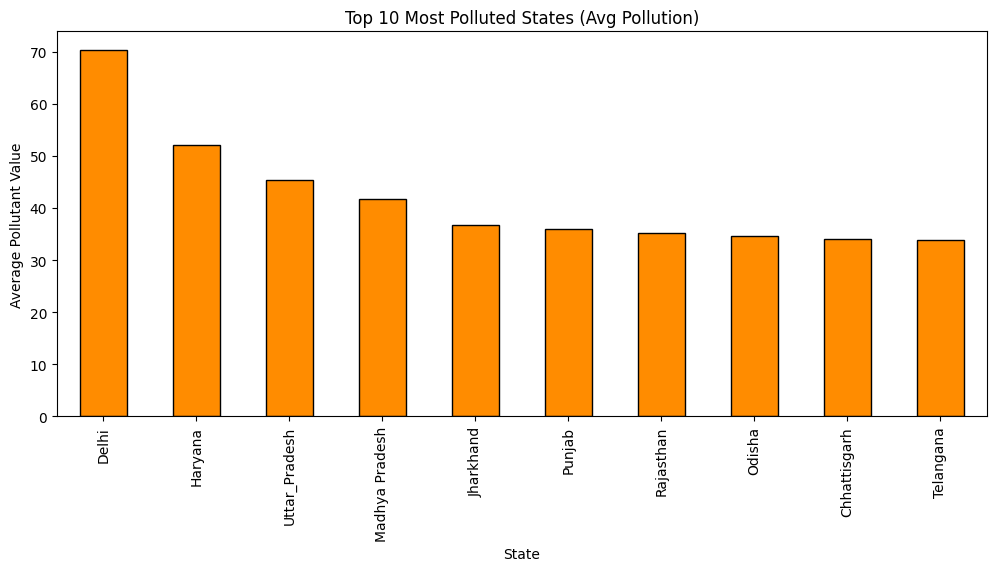

In [12]:
plt.figure(figsize=(12, 5))
df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 10 Most Polluted States (Avg Pollution)')
plt.xlabel('State')
plt.ylabel('Average Pollutant Value')
plt.show()

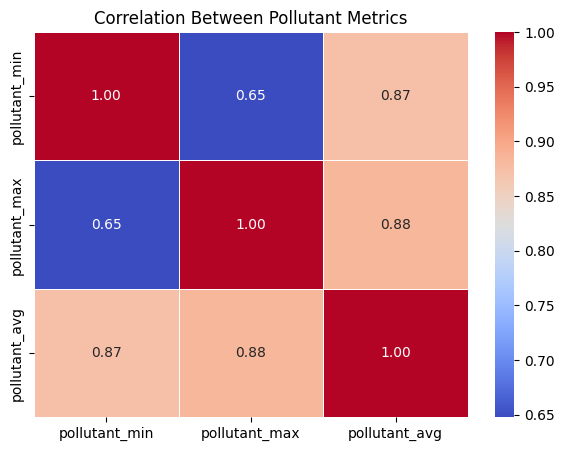

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[['pollutant_min', 'pollutant_max', 'pollutant_avg']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Pollutant Metrics')
plt.show()

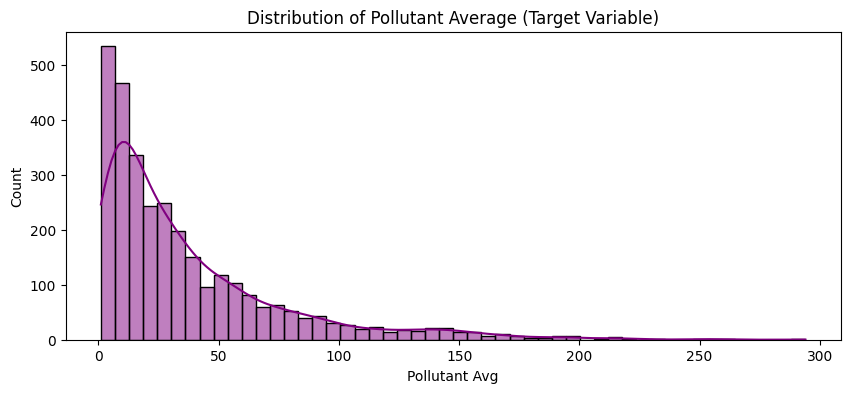

In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(df['pollutant_avg'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Pollutant Average (Target Variable)')
plt.xlabel('Pollutant Avg')
plt.show()

In [15]:
print("Missing before:\n", df.isnull().sum())


df['pollutant_min'].fillna(df['pollutant_min'].median(), inplace=True)
df['pollutant_max'].fillna(df['pollutant_max'].median(), inplace=True)
df['pollutant_avg'].fillna(df['pollutant_avg'].median(), inplace=True)

print("\nMissing after:\n", df.isnull().sum())

Missing before:
 country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    188
pollutant_max    188
pollutant_avg    188
dtype: int64

Missing after:
 country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64


C:\Users\ghosh\AppData\Local\Temp\ipykernel_8424\3006587630.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['pollutant_min'].fillna(df['pollutant_min'].median(), inplace=True)
C:\Users\ghosh\AppData\Local\Temp\ipykernel_8424\3006587630.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [16]:
df['last_update'] = pd.to_datetime(df['last_update'], dayfirst=True)

df['hour'] = df['last_update'].dt.hour
df['day']  = df['last_update'].dt.day
df['month'] = df['last_update'].dt.month

print("New columns added: hour, day, month")
df[['last_update', 'hour', 'day', 'month']].head()

New columns added: hour, day, month


,last_update,hour,day,month
0,2026-03-30 08:00:00,8,30,3
1,2026-03-30 08:00:00,8,30,3
2,2026-03-30 08:00:00,8,30,3
3,2026-03-30 08:00:00,8,30,3
4,2026-03-30 08:00:00,8,30,3


In [17]:
le = LabelEncoder()

df['state_enc']      = le.fit_transform(df['state'])
df['city_enc']       = le.fit_transform(df['city'])
df['pollutant_enc']  = le.fit_transform(df['pollutant_id'])

print("Encoded columns: state_enc, city_enc, pollutant_enc")
df[['state', 'state_enc', 'city', 'city_enc', 'pollutant_id', 'pollutant_enc']].head()

Encoded columns: state_enc, city_enc, pollutant_enc


,state,state_enc,city,city_enc,pollutant_id,pollutant_enc
0,Bihar,3,Bhagalpur,37,NH3,1
1,Bihar,3,Bhagalpur,37,OZONE,3
2,Bihar,3,Bihar Sharif,47,OZONE,3
3,Bihar,3,Buxar,55,PM10,4
4,Bihar,3,Buxar,55,NO2,2


In [18]:

features = ['pollutant_min', 'pollutant_max', 'pollutant_enc',
            'state_enc', 'city_enc', 'latitude', 'longitude',
            'hour', 'day', 'month']

X = df[features]
y = df['pollutant_avg']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=34)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (2640, 10)
X_test:  (661, 10)
y_train: (2640,)
y_test:  (661,)


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   

print("Features scaled successfully!")

Features scaled successfully!


In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
y_pred = lr.predict(X_test_scaled)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
print(comparison.head(10))

   Actual  Predicted
0    18.0      19.14
1    42.0      44.25
2     8.0       7.54
3    74.0      77.90
4    35.0      35.80
5    26.0      22.73
6    10.0      11.15
7    54.0      55.37
8    10.0       8.61
9    28.0      28.89


In [22]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df)

         Feature  Coefficient
1  pollutant_max    21.724280
0  pollutant_min    20.319585
4       city_enc     0.262230
2  pollutant_enc     0.231348
8            day     0.000000
7           hour     0.000000
9          month     0.000000
5       latitude    -0.007400
6      longitude    -0.071161
3      state_enc    -0.093164


In [23]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
print("LINEAR REGRESSION RESULTS")

print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

LINEAR REGRESSION RESULTS
  MAE  : 4.8530
  MSE  : 81.3529
  RMSE : 9.0196
  R²   : 0.9379


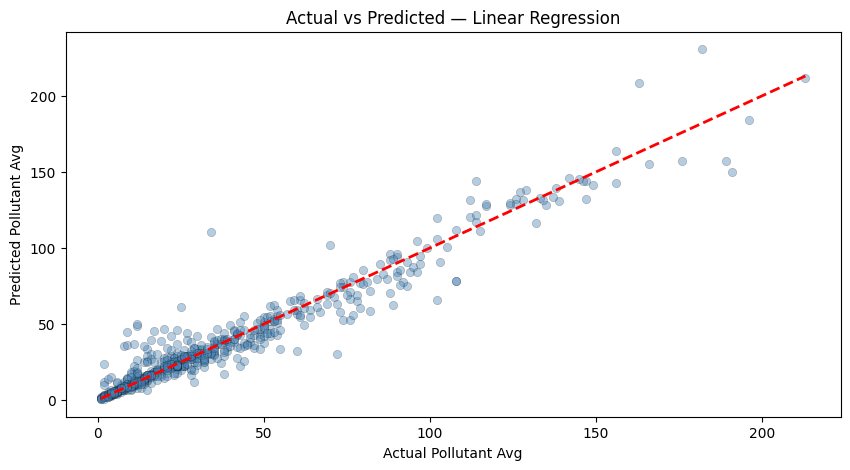

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='black', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
plt.title('Actual vs Predicted — Linear Regression')
plt.xlabel('Actual Pollutant Avg')
plt.ylabel('Predicted Pollutant Avg')
plt.show()

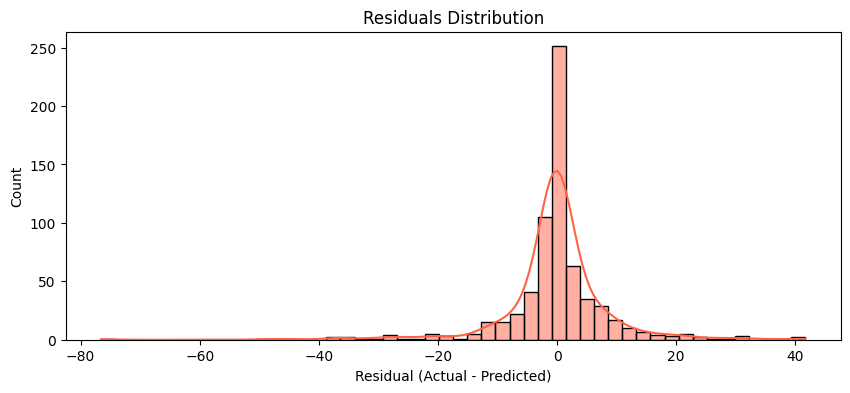

In [25]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=50, kde=True, color='tomato')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

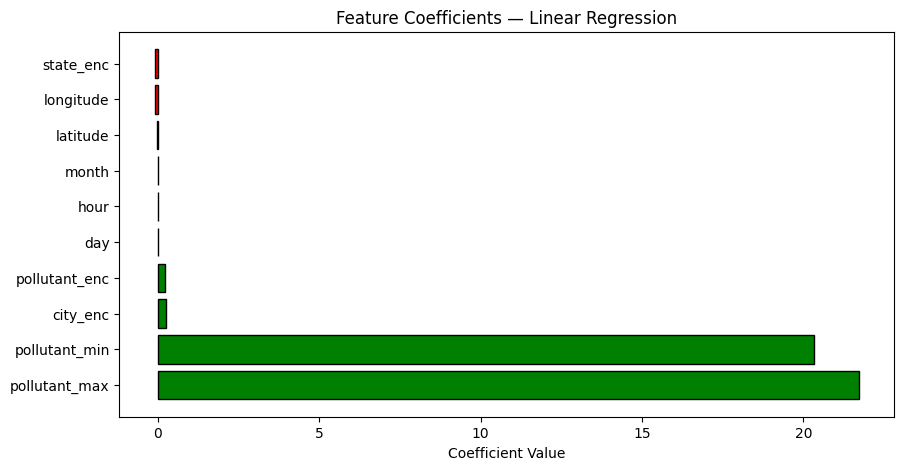

In [26]:
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.title('Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient Value')
plt.show()